# Barcelona Airbnb Housing Displacement Analysis

Airbnb was created with the intention to make unique accommodations and authentic travel experiences accessible to people all around the world. However, the commercialization
of the app, namely the emergence of full-time hosts, has created issues in many cities. In Barcelona, tourism is skyrocketing and locals are not happy about it for
a variety of differnt reasons, including cost-of-living increases and housing shortages. Here, using a dataset from https://insideairbnb.com/get-the-data/, we will
investigate the issue further.

## EDA

After loading the listings.csv data, which includes all airbnb listings in the area, cleaning the dataset, and keeping only columns relevant to our exploration, we begin by checking **room types** listed in order to compare how much of the market is entire homes being offered versus just single rooms. Next, we check the **listings per host**, as a higher number of listings indicates a multi-property owning, commercial operator or a full-time Airbnb renter, and the **listing availability** in days per year, because a listing that is available all the time indicates that it is not someone’s actual home. Checking **HUTB licenses**, or the license for tourist apartments in Barcelona, was messy and ultimately we didn’t rely on it much because there was a lot of data missing and also because single-room renters often don’t have licenses. Finally, we checked **room pricing** per night and the **top neighborhoods** by number of Airbnb listings.


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.colors as mcolors
import geopandas as gpd
import folium

In [ ]:
# LOAD DATA
df = pd.read_csv("listings.csv.gz", low_memory=False)

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Shape: (19410, 79)
Columns: ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'availability_60', '

In [2]:
# BASIC CHECK
# What's missing? What can we actually use?

null_rates = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("\nNull rates (%):")
print(null_rates[null_rates > 0])

# Key columns we need for our project
key_cols = [
    "id", "host_id", "host_listings_count", "host_total_listings_count",
    "neighbourhood_cleansed", "room_type", "price",
    "minimum_nights", "maximum_nights",
    "availability_365", "availability_90", "availability_30",
    "number_of_reviews", "reviews_per_month",
    "calculated_host_listings_count",
    "license"
]

print("\nNull rates for KEY columns only:")
print(null_rates[null_rates.index.isin(key_cols)])


Null rates (%):
calendar_updated               100.000000
host_neighbourhood              55.574446
neighborhood_overview           53.704276
neighbourhood                   53.704276
host_about                      36.939722
license                         28.232870
review_scores_checkin           25.723854
review_scores_accuracy          25.718702
review_scores_value             25.718702
review_scores_location          25.718702
review_scores_cleanliness       25.713550
review_scores_communication     25.708398
reviews_per_month               25.703246
review_scores_rating            25.703246
last_review                     25.703246
first_review                    25.703246
host_location                   24.224626
beds                            21.545595
price                           21.298300
estimated_revenue_l365d         21.298300
bathrooms                       21.184956
host_response_time              16.105100
host_response_rate              16.105100
host_acceptance_r


Room type distribution:
room_type
Entire home/apt    11789
Private room        7417
Shared room          110
Hotel room            94
Name: count, dtype: int64
room_type
Entire home/apt    60.7%
Private room       38.2%
Shared room         0.6%
Hotel room          0.5%
Name: proportion, dtype: object


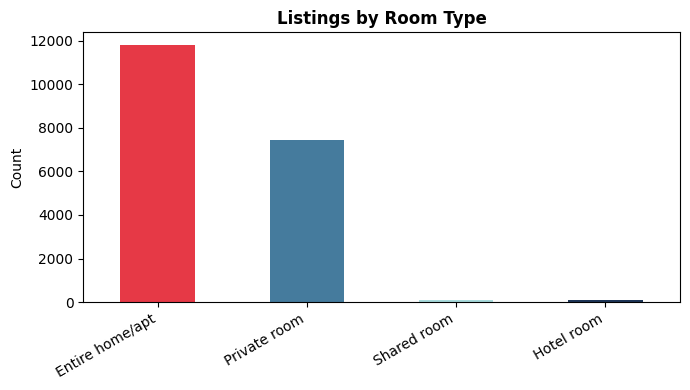

In [3]:
# ROOM TYPE BREAKDOWN
# How much of the market is entire homes vs shared?

print("\nRoom type distribution:")
print(df["room_type"].value_counts())
print(df["room_type"].value_counts(normalize=True).mul(100).round(1).astype(str) + "%")

fig, ax = plt.subplots(figsize=(7, 4))
df["room_type"].value_counts().plot(kind="bar", ax=ax, color=["#e63946","#457b9d","#a8dadc","#1d3557"])
ax.set_title("Listings by Room Type", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("room_type_distribution.png", dpi=150)
plt.show()


calculated_host_listings_count — summary stats:
count    19410.000000
mean        61.671716
std        122.900150
min          1.000000
25%          2.000000
50%          7.000000
75%         40.000000
max        514.000000
Name: calculated_host_listings_count, dtype: float64
  Listings where host has >1 listings: 76.3%
  Listings where host has >2 listings: 67.5%
  Listings where host has >5 listings: 55.3%
  Listings where host has >10 listings: 45.4%
  Listings where host has >20 listings: 34.8%


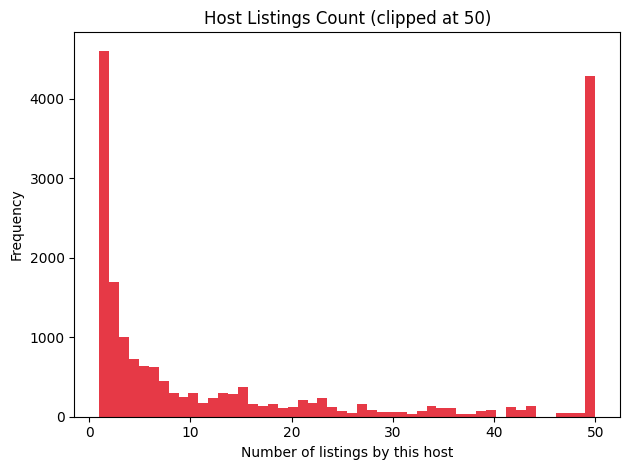

In [4]:
# HOST LISTINGS COUNT (the key commercialization signal)
# Most "sharing economy" hosts have 1 listing.
# Multi-listing hosts are likely commercial operators.

col = "calculated_host_listings_count"  # use this over host_listings_count (more reliable)

print(f"\n{col} — summary stats:")
print(df[col].describe())

# How many hosts have more than 1, 5, 10 listings?
for threshold in [1, 2, 5, 10, 20]:
    pct = (df[col] > threshold).mean() * 100
    print(f"  Listings where host has >{threshold} listings: {pct:.1f}%")


# Left: full distribution (will be very skewed)
df[col].clip(upper=50).plot(kind="hist", bins=50, color="#e63946")
plt.title("Host Listings Count (clipped at 50)")
plt.xlabel("Number of listings by this host")

plt.tight_layout()
plt.savefig("host_listings_distribution.png", dpi=150)
plt.show()


availability_365 — summary stats:
count    19410.000000
mean       195.091190
std        129.370782
min          0.000000
25%         72.000000
50%        223.000000
75%        318.000000
max        365.000000
Name: availability_365, dtype: float64


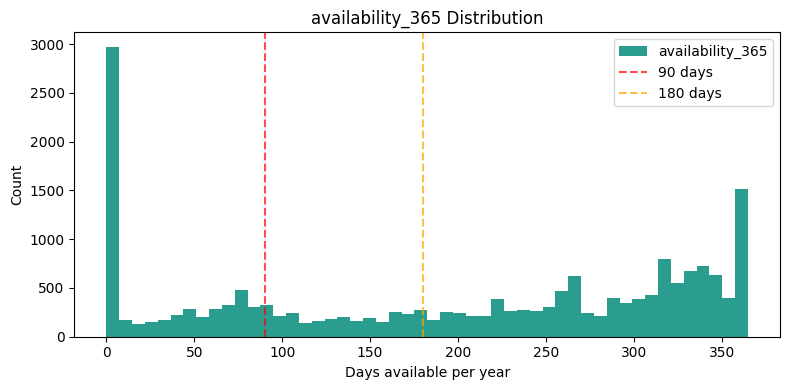


Listings available >180 days/year: 57.0%


In [5]:
# AVAILABILITY
# High availability_365 = listing is always open i.e. not someone's actual home

print("\navailability_365 — summary stats:")
print(df["availability_365"].describe())

fig, ax = plt.subplots(figsize=(8, 4))
df["availability_365"].plot(kind="hist", bins=50, ax=ax, color="#2a9d8f")
ax.set_title("availability_365 Distribution")
ax.set_xlabel("Days available per year")
ax.set_ylabel("Count")
# Notable thresholds
ax.axvline(90, color="red", linestyle="--", alpha=0.7, label="90 days")
ax.axvline(180, color="orange", linestyle="--", alpha=0.7, label="180 days")
ax.legend()
plt.tight_layout()
plt.savefig("availability_distribution.png", dpi=150)
plt.show()

# What % are available more than 180 days/year?
high_avail = (df["availability_365"] > 180).mean() * 100
print(f"\nListings available >180 days/year: {high_avail:.1f}%")



In [6]:
# LICENSE FIELD
# This will be messy.

print("\nLicense field — null rate:")
print(f"  Missing: {df['license'].isnull().mean()*100:.1f}%")

print("\nSample of non-null license values:")
print(df["license"].dropna().value_counts().head(20))

# Flag: does it look like a real HUT license?
# Barcelona HUT licenses follow pattern: HUTB-XXXXXX-XX
def looks_like_hutb(val):
    if pd.isnull(val):
        return "missing"
    val = str(val).strip().upper()
    if val.startswith("HUTB"):
        return "has_hutb"
    if val in ["", "N/A", "NA", "NONE", "NO REQUERIDO", "EXEMPT"]:
        return "blank_or_exempt"
    return "other_value"

df["license_status"] = df["license"].apply(looks_like_hutb)
print("\nLicense status breakdown:")
print(df["license_status"].value_counts())
print(df["license_status"].value_counts(normalize=True).mul(100).round(1).astype(str) + "%")


License field — null rate:
  Missing: 28.2%

Sample of non-null license values:
license
Exempt                                                   4541
HUTB-000000                                                82
HUTB012407                                                 23
AJ000593                                                   22
HB-000087                                                  20
HUTB-012457                                                17
HB-004525                                                  17
AJ000517                                                   16
HUTB-123456                                                14
AJ000680                                                   14
HB-004002                                                  14
HB-045408                                                  14
HB004232                                                   13
ESFCTU00000806900024325300000000000000000HUTB-0002190      12
HB-004688                                  


Price (cleaned) — summary stats:
count    15276.000000
mean       187.312713
std        363.967170
min          9.000000
25%         70.000000
50%        131.000000
75%        215.000000
max      10000.000000
Name: price_clean, dtype: float64


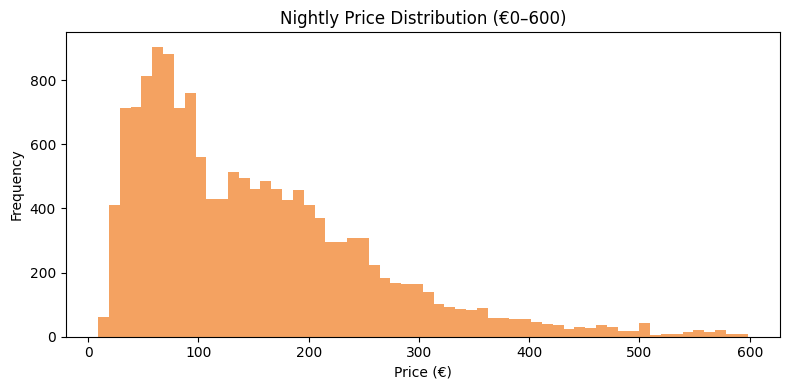

In [7]:
# PRICE
# Clean price column (it's stored as "$1,234.00" string)

df["price_clean"] = (
    df["price"]
    .astype(str)
    .str.replace("[$,]", "", regex=True)
    .pipe(pd.to_numeric, errors="coerce")
)

print("\nPrice (cleaned) — summary stats:")
print(df["price_clean"].describe())

# Remove extreme outliers for visualization
price_filtered = df["price_clean"][(df["price_clean"] > 0) & (df["price_clean"] < 600)]
fig, ax = plt.subplots(figsize=(8, 4))
price_filtered.plot(kind="hist", bins=60, ax=ax, color="#f4a261")
ax.set_title("Nightly Price Distribution (€0–600)")
ax.set_xlabel("Price (€)")
plt.tight_layout()
plt.savefig("price_distribution.png", dpi=150)
plt.show()



Total neighborhoods: 71

Top 15 neighborhoods by listing count:
neighbourhood_cleansed
la Dreta de l'Eixample                   2416
el Raval                                 1519
el Barri Gòtic                           1253
Sant Pere, Santa Caterina i la Ribera    1244
la Vila de Gràcia                        1136
la Sagrada Família                       1102
l'Antiga Esquerra de l'Eixample          1042
Sant Antoni                              1023
el Poble Sec                              855
la Nova Esquerra de l'Eixample            822
Sant Gervasi - Galvany                    590
la Barceloneta                            509
el Fort Pienc                             501
el Poblenou                               488
Sants                                     354
Name: count, dtype: int64


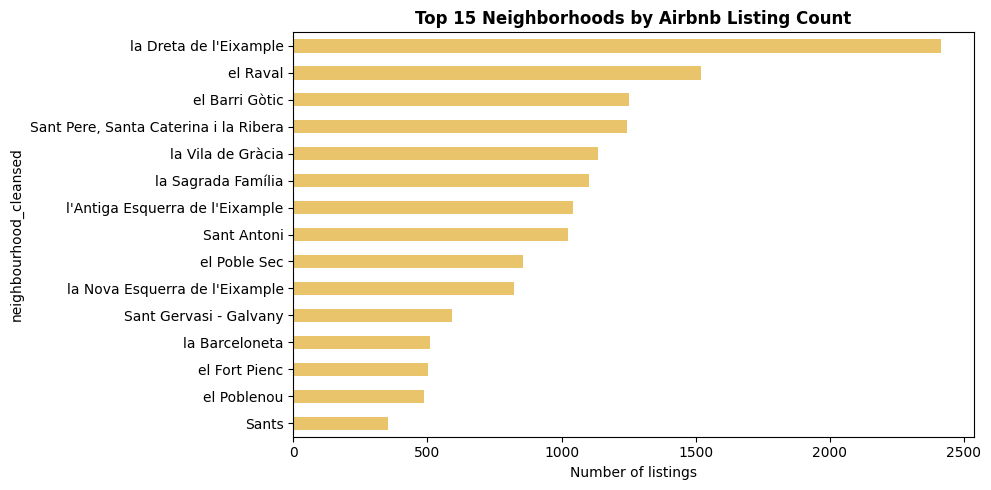


Top 10 neighborhoods by % entire-home listings:
neighbourhood_cleansed
Canyelles                                       100.0%
la Vila Olímpica del Poblenou                    82.9%
la Clota                                         80.0%
la Barceloneta                                   79.4%
Diagonal Mar i el Front Marítim del Poblenou     76.3%
el Poblenou                                      76.2%
les Corts                                        72.6%
la Sagrada Família                               68.6%
el Parc i la Llacuna del Poblenou                66.3%
la Vila de Gràcia                                66.0%
Name: room_type, dtype: object


In [8]:
# NEIGHBORHOOD OVERVIEW
# Which neighborhoods have the most listings?

nbh_counts = df["neighbourhood_cleansed"].value_counts()
print(f"\nTotal neighborhoods: {len(nbh_counts)}")
print("\nTop 15 neighborhoods by listing count:")
print(nbh_counts.head(15))

fig, ax = plt.subplots(figsize=(10, 5))
nbh_counts.head(15).sort_values().plot(kind="barh", ax=ax, color="#e9c46a")
ax.set_title("Top 15 Neighborhoods by Airbnb Listing Count", fontweight="bold")
ax.set_xlabel("Number of listings")
plt.tight_layout()
plt.savefig("neighborhood_counts.png", dpi=150)
plt.show()

# Entire home % by neighborhood (preview of Phase 3)
entire_home_by_nbh = (
    df.groupby("neighbourhood_cleansed")["room_type"]
    .apply(lambda x: (x == "Entire home/apt").mean() * 100)
    .sort_values(ascending=False)
)
print("\nTop 10 neighborhoods by % entire-home listings:")
print(entire_home_by_nbh.head(10).round(1).astype(str) + "%")


In [9]:
# SUMMARY: KEY FINDINGS
print("\n" + "="*55)
print("EDA SUMMARY — KEY NUMBERS TO REMEMBER")
print("="*55)
print(f"Total listings:              {len(df):,}")
print(f"Unique hosts:                {df['host_id'].nunique():,}")
print(f"% Entire home/apt:           {(df['room_type']=='Entire home/apt').mean()*100:.1f}%")
print(f"% Multi-listing hosts:       {(df['calculated_host_listings_count']>1).mean()*100:.1f}%")
print(f"% High availability (>180d): {(df['availability_365']>180).mean()*100:.1f}%")
print(f"% With HUTB license:         {(df['license_status']=='has_hutb').mean()*100:.1f}%")
print(f"% Missing license:           {(df['license_status']=='missing').mean()*100:.1f}%")


EDA SUMMARY — KEY NUMBERS TO REMEMBER
Total listings:              19,410
Unique hosts:                6,620
% Entire home/apt:           60.7%
% Multi-listing hosts:       76.3%
% High availability (>180d): 57.0%
% With HUTB license:         23.2%
% Missing license:           28.2%


Comparing total listings to unique hosts (19,410 vs. 6,620), it is clear that a few multi-property owners and companies are dominating the Airbnb market in the city. Also, people renting out entire homes and renting out places that are available for over half the year are prevalent.


## Commercial Operator Detector
(versus actual person occasionally renting a room in their home)

In this portion, we want to use certain features to predict which listings are from a commercial operator versus a single person. After removing inactive listings (available days per year = 0) and hotel rooms and hostels, as those are obviously commercial, we calculate and normalize our features:

**Host scale**: Count of how many listings this host has

**Listing availability**: Number of days that this is space available for rent

**Minimum nights**: Minimum nights allowed per stay (shorter stay times suggest tourists)

**Entire home**: Is the whole home being rented (i.e. taking an entire property off market for locals)

**Regular arbitrage**: Barcelona requires a tourist license for rentals under 30 days, while rentals over 30 days are classified as residential leases and don't need a license. These operators set minimums of 31-32 days to avoid licensing requirements

Next, we create a commercialization score and scale it (0-100, higher is more commercialized) for each listing by calculating a weighted average of the above features, with host scale, availability, and entire home weighed higher than review frequency and minimum nights. We use K-means clustering to group the rooms in four clusters:

**Casual**: occasionally rents a space in their own home

**Medium-term room rental**: rooms rented out by property management companies who keep their minimum days to 31 to avoid needing a tourist license (“medium-term lease”)

**Medium-term home rental**: same as medium-term room rental, but entire homes

**Commercial**: fully commercial

Using the elbow method and silhouette score, we justified our choice of k = 4 clusters. We also measure confidence for commercial listing predictions by checking if at least 3 out of 5 indicators of commercialization have a score of 0.5 or more.


In [11]:
#LOAD & CLEAN

df = pd.read_csv("listings.csv.gz", low_memory=False)

# Clean price
df["price_clean"] = (
    df["price"].astype(str)
    .str.replace("[$,]", "", regex=True)
    .pipe(pd.to_numeric, errors="coerce")
)

# License flag (from EDA)
def looks_like_hutb(val):
    if pd.isnull(val):
        return 0
    val = str(val).strip().upper()
    return 1 if val.startswith("HUTB") else 0

df["has_valid_license"] = df["license"].apply(looks_like_hutb)

print(f"Loaded {len(df):,} listings")
print(f"Columns available: {df.shape[1]}")

before = len(df)

df = df[df["room_type"] != "Hotel room"]
df = df[~df["name"].str.contains("hostel|Hostel|HOSTEL", na=False)]

after = len(df)
print(f"Removed {before - after} hotel/hostel listings ({before} → {after})")

df = df[df["availability_365"] > 0]
after2 = len(df)
print(f"Removed {after - after2} inactive listings ({after} → {after2})")


Loaded 19,410 listings
Columns available: 81
Removed 142 hotel/hostel listings (19410 → 19268)
Removed 2710 inactive listings (19268 → 16558)


In [12]:
# FEATURE ENGINEERING
# Each feature captures a different dimension of commercial behavior.
# Higher value = more commercial in every case (important for scoring).

# 1a. Host scale — how many listings does this host have?
#     Use calculated_host_listings_count (more reliable than host_listings_count)
df["feat_host_scale"] = df["calculated_host_listings_count"].fillna(1)

# 1b. Availability — always-on = not your actual home
#     Clip at 365, fill missing with median

df["feat_availability"] = df["availability_365"].fillna(
    df["availability_365"].median()
)

# 1c. Minimum nights — low minimum = optimized for tourists, not longer stays
#     INVERT: low minimum_nights → high commercial score
# 0 = long stay (>30), 0.5 = medium (7-30), 1 = tourist (1-6)
def min_nights_category(n):
    if n <= 6:
        return 1.0    # tourist optimized
    elif n <= 30:
        return 0.5    # medium
    else:
        return 0.0    # long stay / regulatory arbitrage

df["feat_short_min_nights"] = df["minimum_nights"].apply(min_nights_category)

# 1d. Entire home — takes the whole unit off the residential market
df["feat_entire_home"] = (df["room_type"] == "Entire home/apt").astype(int)

# 1e. Feature specifically designed to catch regulatory arbitrage
# Scores highest for listings with minimums just above 30 days
df["feat_regulatory_arbitrage"] = (
    df["minimum_nights"].between(30, 35)
).astype(int)


# Collect all feature columns
feature_cols = [
    "feat_host_scale",
    "feat_availability",
    "feat_short_min_nights",
    "feat_entire_home",
    "feat_regulatory_arbitrage"]

print("\nFeature summary (raw, before scaling):")
print(df[feature_cols].describe().round(2))



Feature summary (raw, before scaling):
       feat_host_scale  feat_availability  feat_short_min_nights  \
count         16558.00           16558.00               16558.00   
mean             69.31             226.86                   0.59   
std             128.41             110.55                   0.48   
min               1.00               1.00                   0.00   
25%               2.00             131.00                   0.00   
50%              11.00             256.00                   1.00   
75%              49.00             326.00                   1.00   
max             514.00             365.00                   1.00   

       feat_entire_home  feat_regulatory_arbitrage  
count          16558.00                   16558.00  
mean               0.67                       0.39  
std                0.47                       0.49  
min                0.00                       0.00  
25%                0.00                       0.00  
50%                1.00      

In [13]:
# NORMALIZE FEATURES TO 0–1
# MinMaxScaler so no single feature dominates due to scale.
# host_scale can be 1-50+, availability is 0-365, etc.

scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(df[feature_cols])
features_df = pd.DataFrame(features_scaled, columns=feature_cols, index=df.index)

print("\nFeatures after scaling (should all be 0–1):")
print(features_df.describe().round(2))



Features after scaling (should all be 0–1):
       feat_host_scale  feat_availability  feat_short_min_nights  \
count         16558.00           16558.00               16558.00   
mean              0.13               0.62                   0.59   
std               0.25               0.30                   0.48   
min               0.00               0.00                   0.00   
25%               0.00               0.36                   0.00   
50%               0.02               0.70                   1.00   
75%               0.09               0.89                   1.00   
max               1.00               1.00                   1.00   

       feat_entire_home  feat_regulatory_arbitrage  
count          16558.00                   16558.00  
mean               0.67                       0.39  
std                0.47                       0.49  
min                0.00                       0.00  
25%                0.00                       0.00  
50%                1.00 

In [14]:
# BUILD COMMERCIALIZATION SCORE
# Weighted average of all features → single score 0–100.
#
# Weights reflect relative importance to commercial detection:
# - Host scale and entire home are the strongest signals
# - Availability matters a lot too
# - review freq, min nights are supporting signals

weights = {
    "feat_host_scale":        0.30,  # strongest signal — multi-property = commercial
    "feat_entire_home":       0.30,  # whole apt off housing market
    "feat_availability":      0.20,  # always available = not your home
    "feat_short_min_nights":  0.10, # tourist-optimized
    "feat_regulatory_arbitrage": 0.10  # regulatory risk increases commercial likelihood

}

# Verify weights sum to 1
assert abs(sum(weights.values()) - 1.0) < 1e-9, "Weights must sum to 1"

score = sum(features_df[col] * w for col, w in weights.items()) * 100
df["commercialization_score"] = score.round(1)

print("\nCommercialization Score — summary stats:")
print(df["commercialization_score"].describe().round(2))


Commercialization Score — summary stats:
count    16558.00
mean        46.26
std         18.08
min          0.40
25%         29.90
50%         49.40
75%         58.50
max         90.70
Name: commercialization_score, dtype: float64


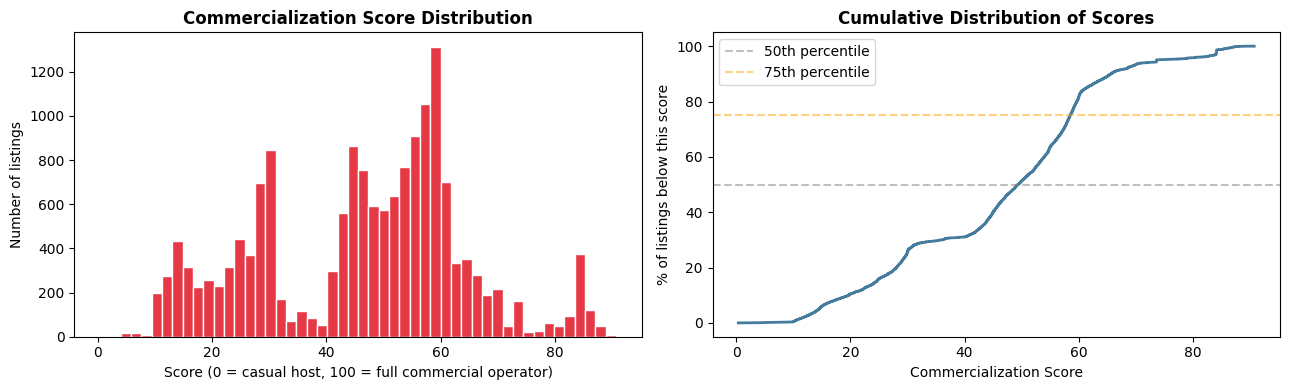

In [15]:
# VISUALIZE THE SCORE DISTRIBUTION
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
df["commercialization_score"].plot(
    kind="hist", bins=50, ax=axes[0], color="#e63946", edgecolor="white"
)
axes[0].set_title("Commercialization Score Distribution", fontweight="bold")
axes[0].set_xlabel("Score (0 = casual host, 100 = full commercial operator)")
axes[0].set_ylabel("Number of listings")

# Cumulative distribution — what % of listings exceed a given score?
sorted_scores = df["commercialization_score"].sort_values()
axes[1].plot(sorted_scores.values, np.linspace(0, 100, len(sorted_scores)),
             color="#457b9d", linewidth=2)
axes[1].set_title("Cumulative Distribution of Scores", fontweight="bold")
axes[1].set_xlabel("Commercialization Score")
axes[1].set_ylabel("% of listings below this score")
axes[1].axhline(50, color="gray", linestyle="--", alpha=0.5, label="50th percentile")
axes[1].axhline(75, color="orange", linestyle="--", alpha=0.5, label="75th percentile")
axes[1].legend()

plt.tight_layout()
plt.savefig("score_distribution.png", dpi=150)
plt.show()

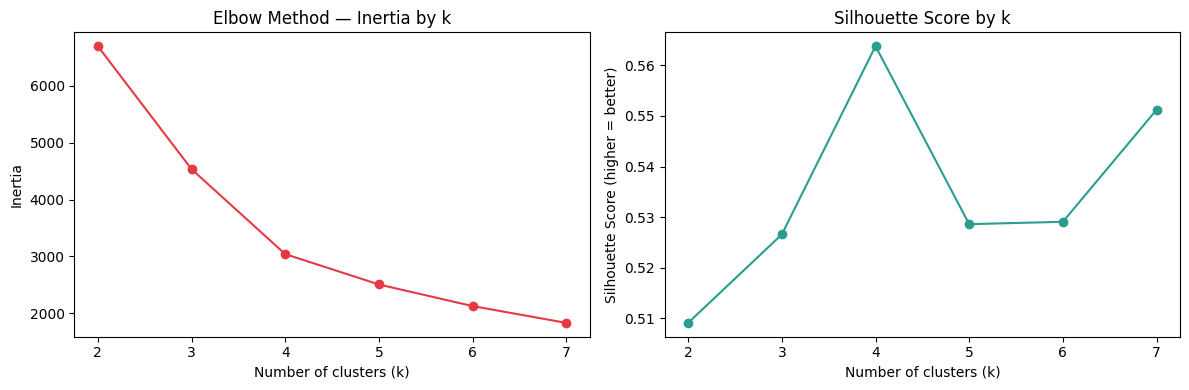


Silhouette scores by k:
  k=2: 0.5091
  k=3: 0.5266
  k=4: 0.5638
  k=5: 0.5286
  k=6: 0.5291
  k=7: 0.5512

Cluster sizes:
operator_type
commercial                 7062
medium_term_home_rental    4056
casual                     2849
medium_term_room_rental    2591
Name: count, dtype: int64
operator_type
commercial                 42.7%
medium_term_home_rental    24.5%
casual                     17.2%
medium_term_room_rental    15.6%
Name: proportion, dtype: object

Mean commercialization score by cluster:
operator_type
casual                     22.1
commercial                 55.7
medium_term_home_rental    58.2
medium_term_room_rental    28.3
Name: commercialization_score, dtype: float64


In [16]:
# KMEANS CLUSTERING
# Group listings into 4 clusters: casual / informal room rental/ small operator / commercial
# We use the scaled features (not the score) for clustering,
# so the model sees all dimensions, not just our weighted summary.

# First: check if k=4 is actually the right number (elbow + silhouette)
inertias = []
silhouettes = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(features_df)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(features_df, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_range, inertias, "o-", color="#e63946")
axes[0].set_title("Elbow Method — Inertia by k")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_range, silhouettes, "o-", color="#2a9d8f")
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score (higher = better)")

plt.tight_layout()
plt.savefig("kmeans_evaluation.png", dpi=150)
plt.show()

print("\nSilhouette scores by k:")
for k, s in zip(k_range, silhouettes):
    print(f"  k={k}: {s:.4f}")

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["cluster_raw"] = kmeans.fit_predict(features_df)

# Re-label clusters by mean commercialization score so they're interpretable
cluster_mean_scores = df.groupby("cluster_raw")["commercialization_score"].mean()
score_rank = cluster_mean_scores.rank().astype(int)
label_map = {
    score_rank[score_rank == 1].index[0]: "casual",
    score_rank[score_rank == 2].index[0]: "medium_term_room_rental",
    score_rank[score_rank == 3].index[0]: "commercial",
    score_rank[score_rank == 4].index[0]: "medium_term_home_rental"}
df["operator_type"] = df["cluster_raw"].map(label_map)

print("\nCluster sizes:")
print(df["operator_type"].value_counts())
print(df["operator_type"].value_counts(normalize=True).mul(100).round(1).astype(str) + "%")

print("\nMean commercialization score by cluster:")
print(df.groupby("operator_type")["commercialization_score"].mean().round(1))



                         calculated_host_listings_count  minimum_nights  availability_365
operator_type                                                                            
casual                                              8.5             2.2             216.3
commercial                                         63.3             5.6             228.5
medium_term_home_rental                            94.9            31.6             229.1
medium_term_room_rental                           112.5            37.3             230.5
operator_type            room_type      
casual                   Private room        97.3
                         Shared room          2.7
commercial               Entire home/apt    100.0
medium_term_home_rental  Entire home/apt    100.0
medium_term_room_rental  Private room        99.5
                         Shared room          0.5

Cluster profiles (mean values):
operator_type              casual  commercial  medium_term_home_rental  \
feat_host_sc

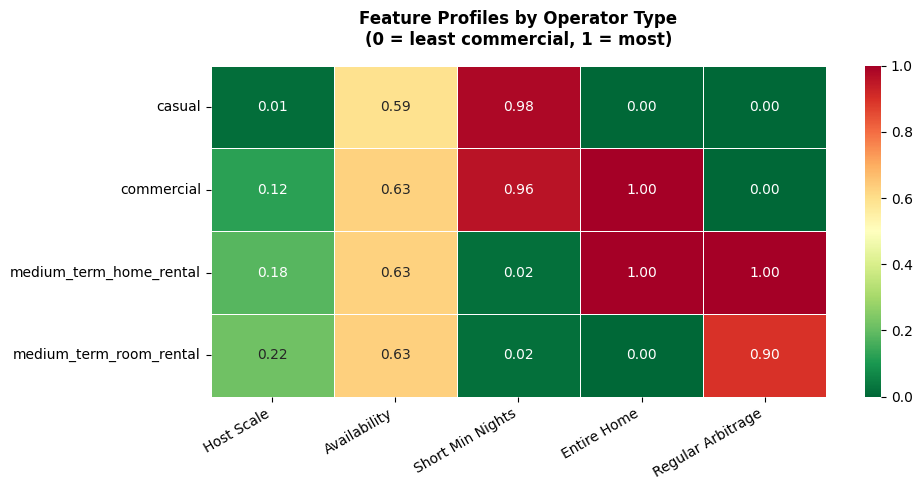

In [17]:
# CLUSTER PROFILE
# What does each cluster actually look like?


print(df.groupby("operator_type")[["calculated_host_listings_count",
                                    "minimum_nights",
                                    "availability_365"]].mean().round(1).to_string())
print(df.groupby("operator_type")["room_type"].value_counts(normalize=True).mul(100).round(1).to_string())

profile_cols = feature_cols + ["commercialization_score", "price_clean"]
profile = df.groupby("operator_type")[profile_cols].mean().round(2)
print("\nCluster profiles (mean values):")
print(profile.T)

fig, ax = plt.subplots(figsize=(10, 5))

# Use scaled feature means per cluster for the heatmap
features_df["operator_type"] = df["operator_type"].values

heatmap_data = features_df.groupby("operator_type")[feature_cols].mean()
heatmap_data.columns = [
    "Host Scale", "Availability",
    "Short Min Nights", "Entire Home", "Regular Arbitrage"
]

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",      # red = more commercial, green = less
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    vmin=0, vmax=1
)

ax.set_title("Feature Profiles by Operator Type\n(0 = least commercial, 1 = most)",
             fontweight="bold", pad=15)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("cluster_heatmap.png", dpi=150)
plt.show()

In [18]:
#SPOT-CHECK — MANUAL VALIDATION

check_cols = {
    "name": "Listing Name",
    "calculated_host_listings_count": "# Host Listings",
    "availability_365": "Avail/yr",
    "room_type": "Room Type",
    "minimum_nights": "Min Nights",
    "reviews_per_month": "Rev/mo",
    "price_clean": "Price €",
    "neighbourhood_cleansed": "Neighbourhood",
    "commercialization_score": "Score",
}

# Dynamically get actual cluster names from the data to avoid hardcoding errors
manual_val_clusters = sorted(df["operator_type"].unique())

for cluster in manual_val_clusters:
    cluster_df = df[df["operator_type"] == cluster]
    n = min(10, len(cluster_df))
    sample = (
        cluster_df
        .sample(n, random_state=1)
        .rename(columns=check_cols)
        [list(check_cols.values())]
        .reset_index(drop=True)
    )
    # Truncate long listing names
    sample["Listing Name"] = sample["Listing Name"].str[:40]

    print(f"\n{'='*40}")
    print(f"  {cluster.upper().replace('_',' ')}  (n={len(cluster_df):,})")
    print(f"{'='*40}")
    print(sample.to_string(index=True))



  CASUAL  (n=2,849)
                               Listing Name  # Host Listings  Avail/yr     Room Type  Min Nights  Rev/mo  Price €                          Neighbourhood  Score
0                     very very lovely room               15       365  Private room           1     NaN    228.0  Sant Pere, Santa Caterina i la Ribera   30.8
1  Chic & Modern Double Bed in Elegant BCN                 3       131  Private room          28    0.13      NaN        l'Antiga Esquerra de l'Eixample   12.3
2              Stay in the center for three               13       361  Private room           1    4.81     75.0                         el Barri Gòtic   30.5
3  Family Suite - Catalonia Barcelona Plaza                7       339  Private room           1     NaN    606.0                            Hostafrancs   28.9
4  Suite Private Bathroom super center Born                3       316  Private room           1    1.46     99.0  Sant Pere, Santa Caterina i la Ribera   27.4
5          Room for

In [19]:
# HIGH CONFIDENCE FLAGS
# A listing is "high confidence commercial" when at least 2 of 3
# key signals are above 0.5 (scaled). Gives a cleaner subset
# for Phase 3 without discarding the full scored dataset.
signal_cols = [
    "feat_host_scale",
    "feat_availability",
    "feat_short_min_nights",
    "feat_entire_home",
    "feat_regulatory_arbitrage"
]

# Count how many signals are above 0.5 per listing
# (use the scaled features we already computed)
df["signals_fired"] = (features_df[signal_cols] > 0.5).sum(axis=1)

# High confidence = 3 or more signals
df["high_confidence_commercial"] = (df["signals_fired"] >= 3).astype(int)

# How many listings meet the bar?
hcc = df[df["high_confidence_commercial"] == 1]
print(f"High confidence commercial listings: {len(hcc):,} ({len(hcc)/len(df)*100:.1f}%)")

# How does it break down by cluster?
print("\nHigh confidence % by operator type:")
print(
    df.groupby("operator_type")["high_confidence_commercial"]
    .mean()
    .mul(100)
    .round(1)
    .astype(str) + "%"
)

# Sanity check — what does a high confidence listing look like?
print("\nSample high confidence commercial listings:")
sample_hcc = (
    hcc.sample(5, random_state=42)
    .rename(columns=check_cols)
    [list(check_cols.values()) + ["signals_fired"]]
    .reset_index(drop=True)
)
sample_hcc["Listing Name"] = sample_hcc["Listing Name"].str[:40]
print(sample_hcc.to_string())

# FIX: 'medium_term_operator' was a stale label — the cluster was renamed
# to 'medium_term_home_rental' and 'medium_term_room_rental'. Combine both.
med_term = df[df["operator_type"].isin(["medium_term_home_rental", "medium_term_room_rental"])]
pct_31_32 = (med_term["minimum_nights"].isin([31, 32])).mean() * 100
print(f"\n% of medium-term listings with 31 or 32 day minimum: {pct_31_32:.1f}%")
print(f"Total medium-term listings: {len(med_term):,}")


High confidence commercial listings: 7,546 (45.6%)

High confidence % by operator type:
operator_type
casual                      0.0%
commercial                 62.0%
medium_term_home_rental    70.9%
medium_term_room_rental    11.3%
Name: high_confidence_commercial, dtype: object

Sample high confidence commercial listings:
                               Listing Name  # Host Listings  Avail/yr        Room Type  Min Nights  Rev/mo  Price €                    Neighbourhood  Score  signals_fired
0  Spacious Apartment Amidst Barcelona’s To               55       323  Entire home/apt          32    0.30    107.0  l'Antiga Esquerra de l'Eixample   60.9              3
1         Luxury for 6. Rambla / Diputació.                5       261  Entire home/apt           1    3.15    269.0           la Dreta de l'Eixample   54.5              3
2            Sea view Barceloneta apartment                4       322  Entire home/apt           2    6.70    274.0                   la Barceloneta   57.8 

In [20]:
# SAVE OUTPUT

output_cols = [
    "id", "host_id", "neighbourhood_cleansed", "room_type",
    "latitude", "longitude", "price_clean",
    "calculated_host_listings_count", "availability_365",
    "reviews_per_month", "minimum_nights",
    "commercialization_score", "operator_type",
    "high_confidence_commercial", "signals_fired"
]

df[output_cols].to_csv("listings_scored.csv", index=False)
print("\n✓ Saved listings_scored.csv")

# SUMMARY
print("\n" + "="*55)
print("SUMMARY")
print("="*55)
casual = df[df["operator_type"] == "casual"]
medrom = df[df["operator_type"] == "medium_term_room_rental"]
medhom = df[df["operator_type"] == "medium_term_home_rental"]
comm = df[df["operator_type"] == "commercial"]
print(f"Casual hosts:        {len(casual):,} ({len(casual)/len(df)*100:.1f}%)")
print(f"Medium-term home rental:  {len(medhom):,} ({len(medhom)/len(df)*100:.1f}%)")
print(f"Medium-term room rental:      {len(medrom):,} ({len(medrom)/len(df)*100:.1f}%)")
print(f"Commercial operators: {len(comm):,} ({len(comm)/len(df)*100:.1f}%)")
print(f"\nMean score — casual:           {casual['commercialization_score'].mean():.1f}")
print(f"Mean score — medium-term home rental:{medhom['commercialization_score'].mean():.1f}")
print(f"Mean score — medium-term room rental:    {medrom['commercialization_score'].mean():.1f}")
print(f"Mean score — commercial:        {comm['commercialization_score'].mean():.1f}")
print("="*55)


✓ Saved listings_scored.csv

SUMMARY
Casual hosts:        2,849 (17.2%)
Medium-term home rental:  4,056 (24.5%)
Medium-term room rental:      2,591 (15.6%)
Commercial operators: 7,062 (42.7%)

Mean score — casual:           22.1
Mean score — medium-term home rental:58.2
Mean score — medium-term room rental:    28.3
Mean score — commercial:        55.7


Only 17.2% of listings are actually casual, with the rest being commercial and medium-term, meaning spaces are being rented to tourists and short-term visitors all year round through Airbnb, taking homes and rooms off of the market for people living there permanently.


## Neighborhood pressure index
Now we aggregate our findings into a housing pressure index (HPI) per neighborhood to measure concentration of commercial renting activity and visualize our findings in an interactive map. The way we calculate the HPI is by aggregating a set of metrics using our results from the commercial operator detector  (entire home, high confidence commercial listing, commercialization score, availability, and operator type; normalized to 0-1) and computing a weighted average (higher HPI, more commercialization in the area). We also set a threshold of above 10 listings per neighborhood to be included in the ranking in order to avoid concentrated HPI’s, such as in la Clota where there are four listings of entire homes available year round, giving it a high HPI but very low confidence.




In [23]:
# LOAD DATA
df = pd.read_csv("listings_scored.csv")
geo = gpd.read_file("neighbourhoods.geojson")

print(f"Listings loaded: {len(df):,}")
print(f"Neighbourhoods in geojson: {len(geo)}")
print(f"\nGeoJSON columns: {geo.columns.tolist()}")

# Check the neighborhood column name in geojson
print("\nSample neighbourhood names from geojson:")
print(geo.iloc[:, 0:3].head(10))

print("\nSample neighbourhood names from listings:")
print(df["neighbourhood_cleansed"].value_counts().head(10))


Listings loaded: 16,558
Neighbourhoods in geojson: 75

GeoJSON columns: ['neighbourhood', 'neighbourhood_group', 'geometry']

Sample neighbourhood names from geojson:
                           neighbourhood neighbourhood_group  \
0                               el Raval        Ciutat Vella   
1                         el Barri Gòtic        Ciutat Vella   
2                 la Dreta de l'Eixample            Eixample   
3        l'Antiga Esquerra de l'Eixample            Eixample   
4         la Nova Esquerra de l'Eixample            Eixample   
5                                el Clot          Sant Martí   
6                         la Barceloneta        Ciutat Vella   
7  Sant Pere, Santa Caterina i la Ribera        Ciutat Vella   
8                          el Fort Pienc            Eixample   
9                     la Sagrada Família            Eixample   

                                            geometry  
0  MULTIPOLYGON (((2.17737 41.37532, 2.17852 41.3...  
1  MULTIPOLYGON ((

In [24]:
# BUILD NEIGHBORHOOD-LEVEL METRICS
# Each metric captures a different dimension of housing pressure.

nbh = df.groupby("neighbourhood_cleansed").agg(
    total_listings        = ("id", "count"),
    pct_entire_home       = ("room_type", lambda x: (x == "Entire home/apt").mean() * 100),
    pct_high_confidence   = ("high_confidence_commercial", "mean"),
    mean_comm_score       = ("commercialization_score", "mean"),
    mean_availability     = ("availability_365", "mean"),
    pct_commercial_type   = ("operator_type", lambda x: x.isin(["commercial", "medium_term_room_rental", "medium_term_home_rental"]).mean() * 100),
).reset_index()

nbh = nbh.rename(columns={"neighbourhood_cleansed": "neighbourhood"})

print(f"\nNeighbourhoods with data: {len(nbh)}")
print("\nTop 10 by total listings:")
print(nbh.nlargest(10, "total_listings")[["neighbourhood", "total_listings"]].to_string())


Neighbourhoods with data: 71

Top 10 by total listings:
                            neighbourhood  total_listings
49                 la Dreta de l'Eixample            2173
43                               el Raval            1260
28                         el Barri Gòtic            1095
18  Sant Pere, Santa Caterina i la Ribera            1073
67                      la Vila de Gràcia             996
58                     la Sagrada Família             946
45        l'Antiga Esquerra de l'Eixample             890
13                            Sant Antoni             868
40                           el Poble Sec             736
56         la Nova Esquerra de l'Eixample             698


In [25]:
# COMPUTE HOUSING PRESSURE INDEX (HPI)
# Normalize each metric to 0–1, then compute weighted average.
# Higher score = more pressure on residential housing.

hpi_features = [
    "pct_entire_home",
    "pct_high_confidence",
    "mean_comm_score",
    "mean_availability",
    "pct_commercial_type",
]

scaler = MinMaxScaler()
nbh_scaled = nbh.copy()
nbh_scaled[hpi_features] = scaler.fit_transform(nbh[hpi_features])

# entire home and confirmed commercial operators
# are the strongest signals of housing displacement
hpi_weights = {
    "pct_entire_home":      0.25,
    "pct_high_confidence":  0.25,
    "mean_comm_score":      0.25,
    "pct_commercial_type":  0.20,
    "mean_availability":    0.05,
}

assert abs(sum(hpi_weights.values()) - 1.0) < 1e-9

nbh["hpi"] = sum(
    nbh_scaled[col] * w for col, w in hpi_weights.items()
) * 100

nbh["hpi"] = nbh["hpi"].round(1)

threshold = 10

nbh_reliable = nbh[nbh["total_listings"] >= threshold].copy()

print(f"Neighbourhoods with at least {threshold} listings: {len(nbh_reliable)}")

print("\nTop 10 highest pressure neighbourhoods (thresholded):")
print(
    nbh_reliable.nlargest(10, "hpi")[
        ["neighbourhood", "hpi", "total_listings", "pct_entire_home", "pct_high_confidence"]
    ].to_string(index=False)
)

print("\nBottom 10 lowest pressure neighbourhoods (thresholded):")
print(
    nbh_reliable.nsmallest(10, "hpi")[
        ["neighbourhood", "hpi", "total_listings", "pct_entire_home", "pct_high_confidence"]
    ].to_string(index=False)
)


print("\nHousing Pressure Index — summary:")
print(nbh["hpi"].describe().round(2))

print("\nTop 10 highest pressure neighbourhoods:")
print(
    nbh.nlargest(10, "hpi")[["neighbourhood", "hpi", "total_listings",
                               "pct_entire_home", "pct_high_confidence"]]
    .to_string(index=False)
)

print("\nBottom 10 lowest pressure neighbourhoods:")
print(
    nbh.nsmallest(10, "hpi")[["neighbourhood", "hpi", "total_listings",
                                "pct_entire_home", "pct_high_confidence"]]
    .to_string(index=False)
)


Neighbourhoods with at least 10 listings: 59

Top 10 highest pressure neighbourhoods (thresholded):
                               neighbourhood  hpi  total_listings  pct_entire_home  pct_high_confidence
               la Vila Olímpica del Poblenou 80.1             128        91.406250             0.585938
               Vilapicina i la Torre Llobeta 74.9              74        68.918919             0.621622
                                 el Poblenou 72.8             427        83.138173             0.529274
                                    la Salut 72.3              69        76.811594             0.550725
             l'Antiga Esquerra de l'Eixample 70.8             890        71.685393             0.544944
Diagonal Mar i el Front Marítim del Poblenou 69.9             134        84.328358             0.447761
                                 Sant Antoni 69.5             868        70.391705             0.534562
                              la Barceloneta 69.3             439   

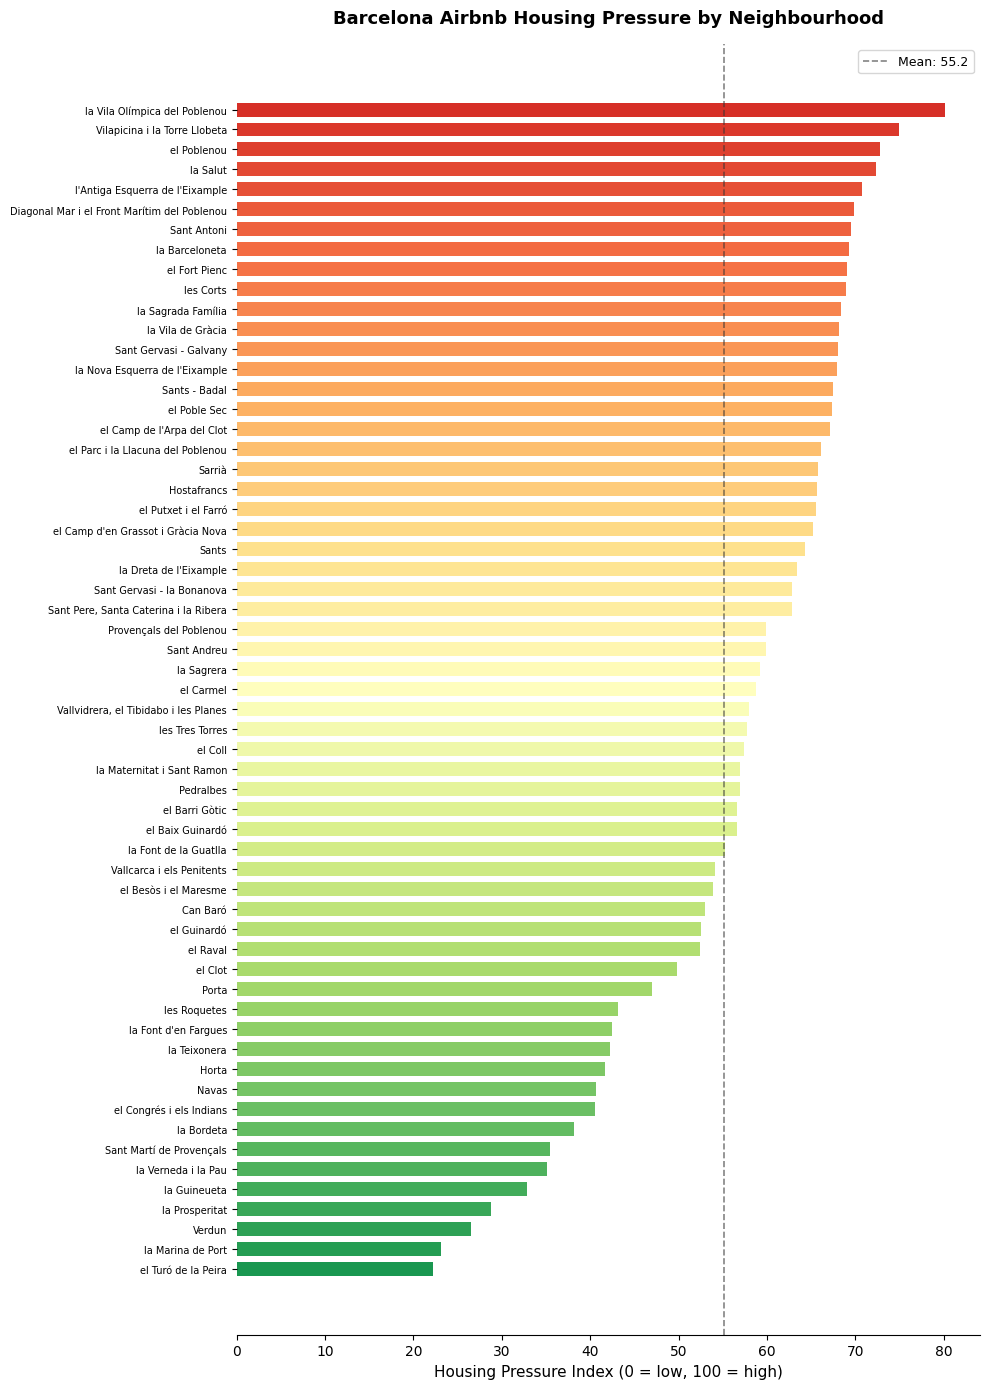

In [26]:
# STATIC VISUALIZATION — BAR CHART
# Ranked bar chart of all neighborhoods by HPI.
# Good for portfolio README / presentations.
import matplotlib.pyplot as plt
import numpy as np

nbh_sorted = nbh_reliable.sort_values("hpi", ascending=True)

fig, ax = plt.subplots(figsize=(10, 14))
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(nbh_sorted)))

bars = ax.barh(nbh_sorted["neighbourhood"], nbh_sorted["hpi"],
               color=colors, edgecolor="none", height=0.7)

ax.set_xlabel("Housing Pressure Index (0 = low, 100 = high)", fontsize=11)
ax.set_title("Barcelona Airbnb Housing Pressure by Neighbourhood",
             fontweight="bold", fontsize=13, pad=15)
ax.axvline(nbh["hpi"].mean(), color="#333", linestyle="--",
           alpha=0.6, linewidth=1.2, label=f"Mean: {nbh['hpi'].mean():.1f}")
ax.legend(fontsize=9)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.savefig("hpi_barchart.png", dpi=150, bbox_inches="tight")
plt.show()

In [27]:
# Merge HPI scores into geodataframe
# Find the right column name to join on
geo_col = [c for c in geo.columns if "neighbourhood" in c.lower() and "group" not in c.lower()][0]
print(f"\nJoining geojson on column: '{geo_col}'")

geo_merged = geo.merge(nbh_reliable, left_on=geo_col, right_on="neighbourhood", how="left")

print(f"Matched neighbourhoods: {geo_merged['hpi'].notna().sum()} / {len(geo_merged)}")

# Check for unmatched neighborhoods
unmatched = geo_merged[geo_merged["hpi"].isna()][geo_col].tolist()
if unmatched:
    print(f"Unmatched (no listing data): {unmatched}")

# Build folium map centered on Barcelona
m = folium.Map(
    location=[41.3851, 2.1734],
    zoom_start=13,
    tiles="CartoDB positron"
)

# Choropleth layer
folium.Choropleth(
    geo_data=geo_merged.__geo_interface__,
    data=nbh_reliable,
    columns=["neighbourhood", "hpi"],
    key_on=f"feature.properties.{geo_col}",
    fill_color="RdYlGn_r",
    fill_opacity=0.75,
    line_opacity=0.3,
    line_color="white",
    legend_name="Housing Pressure Index (0–100)",
    nan_fill_color="#cccccc",
    highlight=True,
).add_to(m)

# Tooltip — click any neighbourhood to see its stats
folium.GeoJson(
    geo_merged.__geo_interface__,
    style_function=lambda f: {
        "fillOpacity": 0,
        "weight": 0,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[geo_col, "hpi", "total_listings",
                "pct_entire_home", "pct_high_confidence"],
        aliases=["Neighbourhood", "HPI Score", "Total Listings",
                 "% Entire Home", "% High Confidence Commercial"],
        localize=True,
        sticky=True,
        labels=True,
        style="""
            background-color: white;
            border: 1px solid #ccc;
            border-radius: 4px;
            font-family: sans-serif;
            font-size: 12px;
            padding: 8px;
        """
    )
).add_to(m)

m.save("barcelona_hpi_map.html")
print("\n✓ Map saved as barcelona_hpi_map.html")
print(f"✓ Map covers {geo_merged['hpi'].notna().sum()} neighbourhoods with HPI data")



Joining geojson on column: 'neighbourhood'
Matched neighbourhoods: 61 / 75
Unmatched (no listing data): ['Sant Genís dels Agudells', 'Montbau', 'la Marina del Prat Vermell', 'Baró de Viver', 'Can Peguera', "la Vall d'Hebron", 'la Clota', 'Canyelles', 'el Bon Pastor', 'la Trinitat Nova', 'Torre Baró', 'Ciutat Meridiana', 'Vallbona', 'la Trinitat Vella']

✓ Map saved as barcelona_hpi_map.html
✓ Map covers 61 neighbourhoods with HPI data



Correlation with HPI:
mean_comm_score        0.981
pct_entire_home        0.959
pct_high_confidence    0.931
pct_commercial_type    0.769
mean_availability      0.159
Name: hpi, dtype: float64


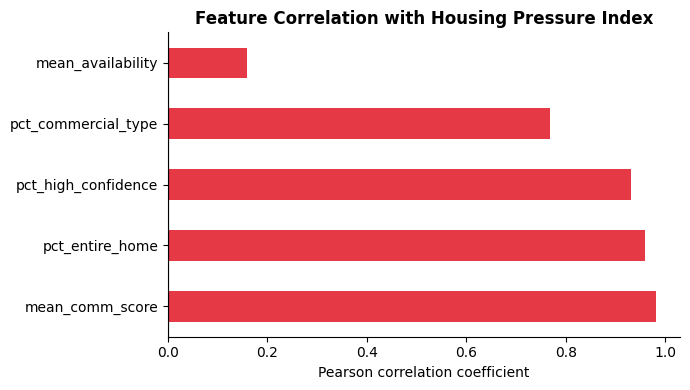

In [28]:
# CORRELATION ANALYSIS
# Which individual metrics drive HPI the most?


print("\nCorrelation with HPI:")
corr = nbh_reliable[hpi_features + ["hpi"]].corr()["hpi"].drop("hpi").sort_values(ascending=False)
print(corr.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#e63946" if v > 0 else "#457b9d" for v in corr.values]
corr.plot(kind="barh", ax=ax, color=colors)
ax.set_title("Feature Correlation with Housing Pressure Index", fontweight="bold")
ax.set_xlabel("Pearson correlation coefficient")
ax.axvline(0, color="black", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("hpi_correlations.png", dpi=150)
plt.show()



In [29]:
# FINAL SUMMARY

high_pressure = nbh_reliable[nbh_reliable["hpi"] >= nbh_reliable["hpi"].quantile(0.75)]
low_pressure  = nbh_reliable[nbh_reliable["hpi"] <= nbh_reliable["hpi"].quantile(0.25)]

print("\n" + "="*55)
print("PHASE 3 SUMMARY — HOUSING PRESSURE INDEX")
print("="*55)
print(f"Neighbourhoods analysed:     {len(nbh_reliable)}")
print(f"Mean HPI:                    {nbh_reliable['hpi'].mean():.1f}")
print(f"Highest pressure:            {nbh_reliable.loc[nbh_reliable['hpi'].idxmax(), 'neighbourhood']} ({nbh_reliable['hpi'].max():.1f})")
print(f"Lowest pressure:             {nbh_reliable.loc[nbh_reliable['hpi'].idxmin(), 'neighbourhood']} ({nbh_reliable['hpi'].min():.1f})")
print(f"\nTop quartile (high pressure) neighbourhoods:")
for _, r in high_pressure.nlargest(5, "hpi").iterrows():
    print(f"  {r['neighbourhood']:<40} HPI: {r['hpi']:.1f}")
print(f"\nBottom quartile (low pressure) neighbourhoods:")
for _, r in low_pressure.nsmallest(5, "hpi").iterrows():
    print(f"  {r['neighbourhood']:<40} HPI: {r['hpi']:.1f}")
print("="*55)


PHASE 3 SUMMARY — HOUSING PRESSURE INDEX
Neighbourhoods analysed:     59
Mean HPI:                    56.3
Highest pressure:            la Vila Olímpica del Poblenou (80.1)
Lowest pressure:             el Turó de la Peira (22.2)

Top quartile (high pressure) neighbourhoods:
  la Vila Olímpica del Poblenou            HPI: 80.1
  Vilapicina i la Torre Llobeta            HPI: 74.9
  el Poblenou                              HPI: 72.8
  la Salut                                 HPI: 72.3
  l'Antiga Esquerra de l'Eixample          HPI: 70.8

Bottom quartile (low pressure) neighbourhoods:
  el Turó de la Peira                      HPI: 22.2
  la Marina de Port                        HPI: 23.1
  Verdun                                   HPI: 26.5
  la Prosperitat                           HPI: 28.8
  la Guineueta                             HPI: 32.8


Out of 49 neighborhoods analyzed, la Vila Olímpica del Poblenou area (80.9) is in the highest scoring HPI neighborhoods, as well as l'Antiga Esquerra de l'Eixample (71) and Vilapicina i la Torre Llobeta (76), with the average HPI being 60.5.

# Conclusions
As of news reports from late 2025, the Spanish government seems to be moving towards tightening rules and regulations concerning
short-term rentals in Barcelona. However, there is a long way to go, given that this dataset was also updated in December 2025.
The full scope of these regulatory changes and their practical implications for property owners, tourists, and the housing market
remain to be seen. As Barcelona continues to grapple with housing affordability and overtourism, the effectiveness of these new
policies will likely take years to fully materialize. As for people visiting Barcelona, or any place, try to be intentional about how you are visiting and where you are choosing to stay.